In [1]:
import euclidemu2 as ee2
import numpy as np


In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))
from wale.CosmologyModel import *
import pandas as pd

cosmotable = np.loadtxt('../data/CosmoTable.dat')
cosmotable_om = cosmotable[:,1]
cosmotable_h = cosmotable[:,2]
cosmotable_w0 = cosmotable[:,3]
cosmotable_sig8 =  cosmotable[:,4]
cosmotable_oc = cosmotable[:,5]

# Define parameter bounds based on min and max values
param_bounds = np.array([
    [np.min(cosmotable_om), cosmotable_om.max()],
    [cosmotable_h.min(), cosmotable_h.max()],
    [cosmotable_w0.min(), cosmotable_w0.max()],
    [cosmotable_sig8.min(), cosmotable_sig8.max()],
    [cosmotable_oc.min(), cosmotable_oc.max()]
])

lh_df = pd.DataFrame(cosmotable[:,1:], columns=["Om", "h", "w0", "sig8", "Oc"])



As_new: 2.1898249043142446e-09 s8_check: 0.8339999999999999 target sigma8: 0.834 input sig8 : 0.8167158851549926
len k_custom: 4990


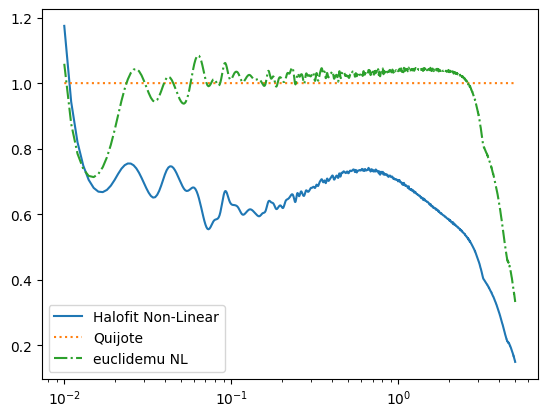

In [23]:
# --- Cosmology parameters ---
h = 0.6711
Ob = 0.049
w = -0.95
wa = 0.0
sigma8 = 0.834
Om = 0.3175
Oc = Om - Ob
ns = 0.9624

import importlib.resources as importlib_res
import importlib_resources
setattr(importlib_res, "files", importlib_resources.files)
setattr(importlib_res, "as_file", importlib_resources.as_file)

import pyccl as ccl

def As_from_sigma8(
    s8_target,
    h,
    Omega_c,
    Omega_b,
    n_s,
    w0,
    wa,
    As_ref=2.1e-9,
):
    # Build reference cosmology
    cosmo_ref = ccl.Cosmology(
        A_s=As_ref,
        h=h,
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        n_s=n_s,
        w0=w0,
        wa=wa,
    )

    # Reference sigma8
    s8_ref = ccl.sigma8(cosmo_ref)

    # Scale As to match target sigma8
    As = As_ref * (s8_target / s8_ref) ** 2.

    # Sanity check with the new As
    cosmo = ccl.Cosmology(
        A_s=As,
        h=h,
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        n_s=n_s,
        w0=w0,
        wa=wa,
    )
    s8_check = ccl.sigma8(cosmo)

    return As, s8_check, s8_ref


As_new, s8_check, s8_0 = As_from_sigma8(sigma8, h=h, Omega_c=Oc, Omega_b=Ob, n_s=ns, w0=w, wa=wa)

print("As_new:", As_new, "s8_check:", s8_check, "target sigma8:", sigma8, "input sig8 :", s8_0)

k_custom = np.arange(1e-2,5,1e-3)
print("len k_custom:", len(k_custom))
dk_custom = k_custom[1]-k_custom[0]

cosmo = ccl.Cosmology(h = h, Omega_c = Oc, Omega_b = Ob, n_s = ns, sigma8=sigma8, w0 = w, wa = wa, transfer_function="boltzmann_class")
cosmo_par = {'As':As_new, 'ns':ns, 'Omb':Ob, 'Omm':Om, 'Omc':Oc, 'h':h, 'mnu':0.0, 'w':w, 'wa':0.0}

redshifts = 0.

k, b = ee2.get_boost(cosmo_par,redshifts,k_custom)
pnl_halofit = ccl.nonlin_matter_power(cosmo, k_custom, 1/(1+redshifts))
plin_halofit = ccl.linear_matter_power(cosmo, k_custom, 1/(1+redshifts))

pnl_ee2 = plin_halofit * (b[0])

k, pnl, plin, b = ee2.get_pnonlin(cosmo_par, redshifts, k_custom)

k_quijote, Pk_quijote = np.loadtxt('/feynman/work/dap/lcs/vt272285/final_codes/WALE/data/w_m_1_Pk_m_z=0.txt', unpack=True)

from scipy.interpolate import CubicSpline
cs = CubicSpline(k_quijote, Pk_quijote)
Pk_quijote = cs(k_custom)

import matplotlib.pyplot as plt
plt.plot(k, pnl_halofit*(h**3)/Pk_quijote, label='Halofit Non-Linear')
# plt.plot(k, plin_halofit*(h**3), label='Halofit Linear')
# plt.plot(k_custom, pnl_ee2, label='EuclidEmu2 boosted', linestyle='dashed')
plt.plot(k_custom, Pk_quijote/Pk_quijote, label='Quijote', linestyle='dotted')
plt.plot(k_custom, pnl[0]/Pk_quijote, label='euclidemu NL', linestyle='dashdot')
# plt.plot(k_custom, plin[0], label='euclidemu Lin', linestyle='dashdot')
plt.xscale('log')
# plt.yscale('log')
plt.legend()

In [6]:
import importlib.resources as importlib_res
import importlib_resources
setattr(importlib_res, "files", importlib_resources.files)
setattr(importlib_res, "as_file", importlib_resources.as_file)
import classy
params = {
    "output": "mPk",
    "P_k_max_1/Mpc": 50.,
    "z_max_pk": 99,
    "modes": "s",
    "lensing": "no",
    "h": h,
    "Omega_cdm": Oc,
    "Omega_b": Ob,
    "Omega_k": 0.,
    "Omega_Lambda": 1 - Om,
    "n_s": ns,
    "N_ur": 3.046,
    "T_cmb": 2.725,
    "A_s": 2e-9,
    "w0_fld": w,
    "wa_fld": wa,
    "non linear": "halofit",
}
model = classy.Class()
model.set(params)
model.compute()
